In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_regression

random_state=142

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/МИФИ Машинное обучение/Классическое машинное обучение/Данные_для_курсовой_Классическое_МО.xlsx')
df = df.drop(columns=['Unnamed: 0'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
display(df.shape)
display(df.info())
#базовая информация

missing = df.isna().sum().sort_values()
display(df[df.isnull().any(axis=1)])
display(f"Kолонки с пропусками: {missing[missing > 0].index.values}")
display(f"Количество дубликатов: {df.duplicated().sum()}")

display(df.describe())

df = df.fillna(df.median())
#cмотрим что есть в датасете, заполняем пропуски

(1001, 213)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


None

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,250.175,...,1,0,0,0,0,0,0,0,0,0


"Kолонки с пропусками: ['BCUT2D_MWHI' 'BCUT2D_MWLOW' 'BCUT2D_CHGHI' 'BCUT2D_CHGLO'\n 'BCUT2D_LOGPHI' 'BCUT2D_LOGPLOW' 'BCUT2D_MRHI' 'MinAbsPartialCharge'\n 'MaxAbsPartialCharge' 'MaxPartialCharge' 'MinPartialCharge'\n 'BCUT2D_MRLOW']"

'Количество дубликатов: 32'

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


/tmp/ipykernel_6675/884385850.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[log_col] = np.log10(df[col])
/tmp/ipykernel_6675/884385850.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[log_col] = np.log10(df[col])
/tmp/ipykernel_6675/884385850.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fram

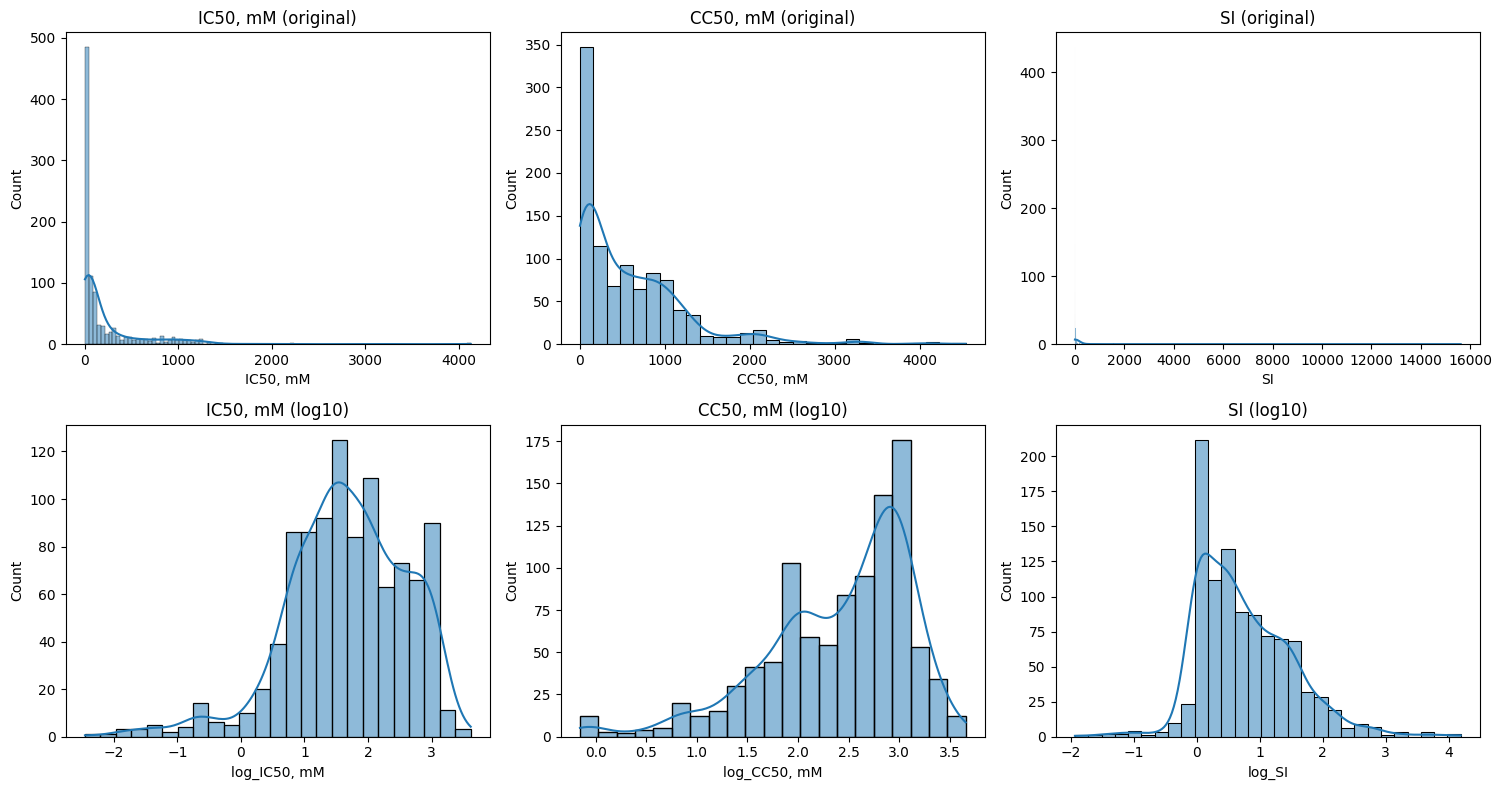

'Skewness:'

'IC50, mM: 3.67'

'CC50, mM: 1.97'

'SI: 18.01'

'log_IC50, mM: -0.74'

'log_CC50, mM: -1.07'

'log_SI: 0.80'

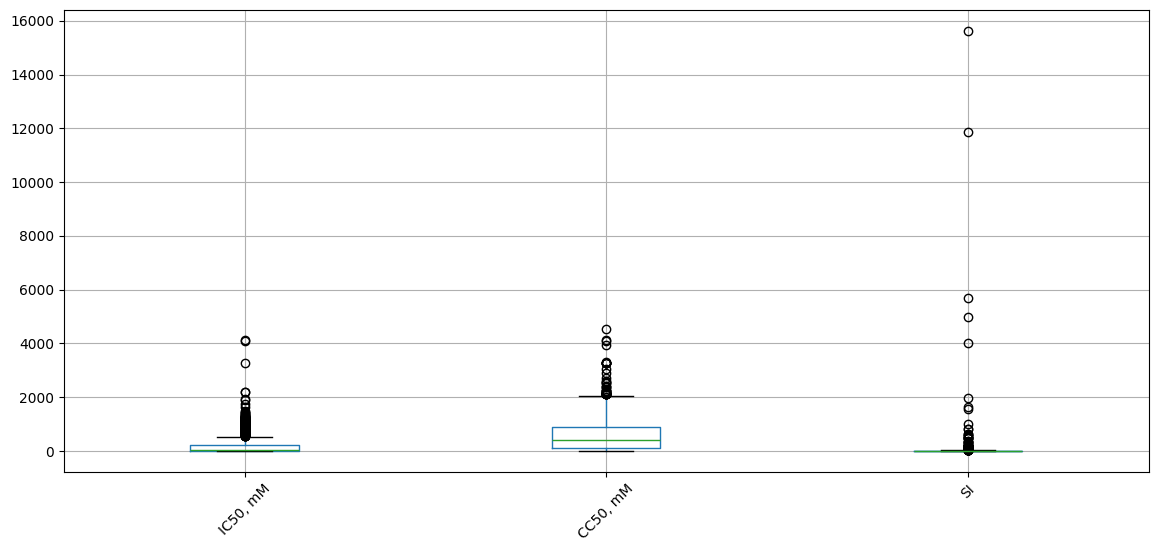

IC50 > median: 0.500
CC50 > median: 0.499
SI > median: 0.500
SI > 8: 0.357


In [ ]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
display(df[targets].describe())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(targets):
  sns.histplot(df[col], kde=True, ax=axes[0,i])
  axes[0,i].set_title(f'{col} (original)')

  log_col = f'log_{col}'
  df[log_col] = np.log10(df[col])
  sns.histplot(df[log_col], kde=True, ax=axes[1,i])
  axes[1,i].set_title(f'{col} (log10)')

plt.tight_layout()
plt.show()

display("Skewness:")
for col in targets + [f'log_{col}' for col in targets]:
  display(f"{col}: {df[col].skew():.2f}")

df[targets].boxplot(figsize=(14, 6), rot=45)
plt.show()


thresholds = {
  'IC50_median': float(df['IC50, mM'].median()),
  'CC50_median': float(df['CC50, mM'].median()),
  'SI_median': float(df['SI'].median()),
  'SI_threshold_8': 8.0
}


class_distr = {
  'IC50 > median': (df['IC50, mM'] > thresholds['IC50_median']).mean(),
  'CC50 > median': (df['CC50, mM'] > thresholds['CC50_median']).mean(),
  'SI > median': (df['SI'] > thresholds['SI_median']).mean(),
  'SI > 8': (df['SI'] > 8).mean()
}

for metric, value in class_distr.items():
    print(f'{metric}: {value:.3f}')


,MolWt,MolLogP,TPSA,NumRotatableBonds,qed,NumHDonors,NumHAcceptors,HeavyAtomCount,FractionCSP3,RingCount
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,348.262234,3.437327,61.400769,3.838162,0.580412,1.181818,4.338661,24.652348,0.542519,3.562438
std,126.946370,2.142706,45.743831,3.262787,0.212230,1.588996,3.206274,9.069124,0.310584,1.574912
min,110.156000,-5.750700,0.000000,0.000000,0.059567,0.000000,0.000000,8.000000,0.000000,0.000000
25%,264.321000,2.449200,29.460000,2.000000,0.442842,0.000000,2.000000,19.000000,0.277778,2.000000
50%,315.457000,3.423600,49.740000,3.000000,0.634981,1.000000,4.000000,22.000000,0.555556,3.000000
75%,409.283000,4.527800,83.760000,5.000000,0.742483,2.000000,5.000000,29.000000,0.857143,4.000000
max,904.777000,12.822200,407.500000,28.000000,0.947265,15.000000,25.000000,63.000000,1.000000,9.000000


'Skewness:'

,0
MolWt,0.999601
MolLogP,-0.272756
TPSA,2.174105
NumRotatableBonds,2.095538
qed,-0.688304
NumHDonors,3.491151
NumHAcceptors,1.765105
HeavyAtomCount,1.001703
FractionCSP3,-0.051291
RingCount,0.821280


'Kurtosis:'

,0
MolWt,0.725488
MolLogP,2.718824
TPSA,8.588279
NumRotatableBonds,7.737869
qed,-0.533197
NumHDonors,18.555930
NumHAcceptors,4.427538
HeavyAtomCount,0.611658
FractionCSP3,-1.299531
RingCount,0.682344


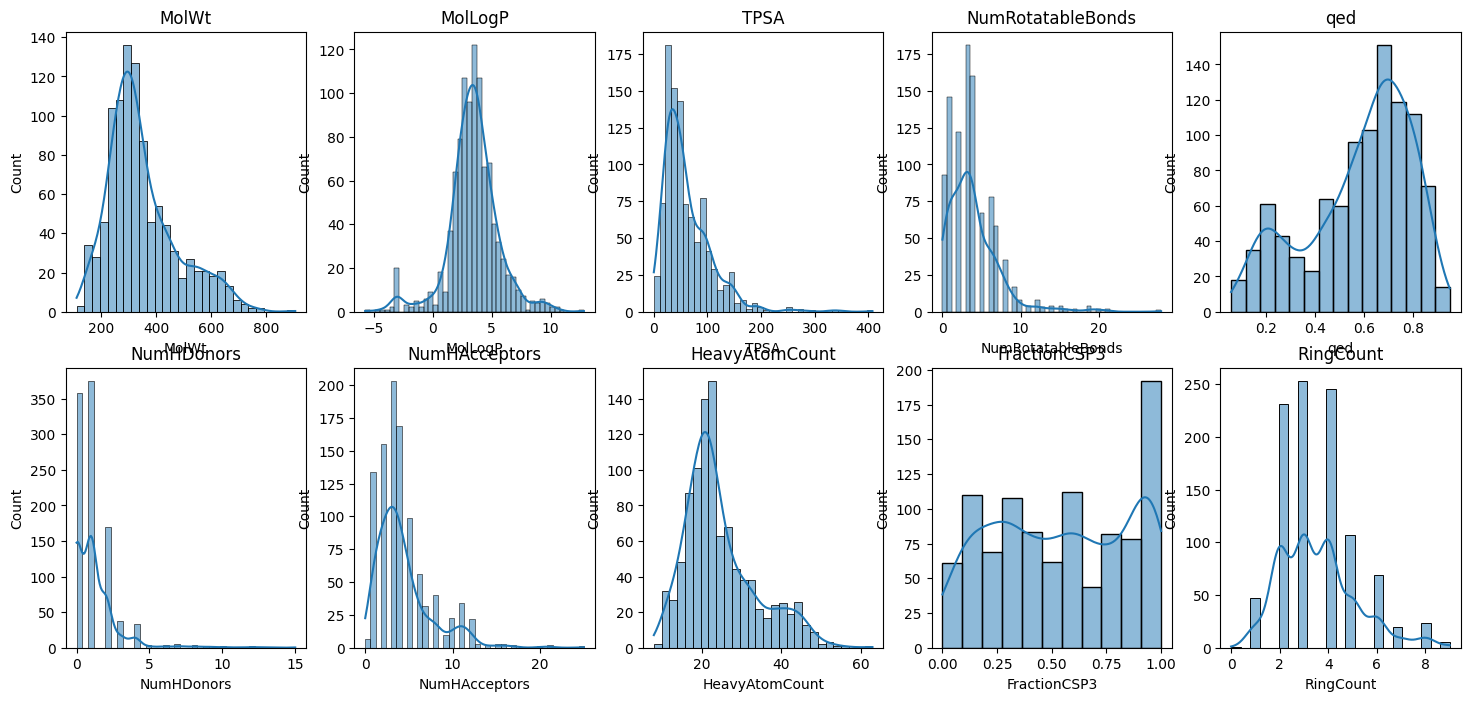

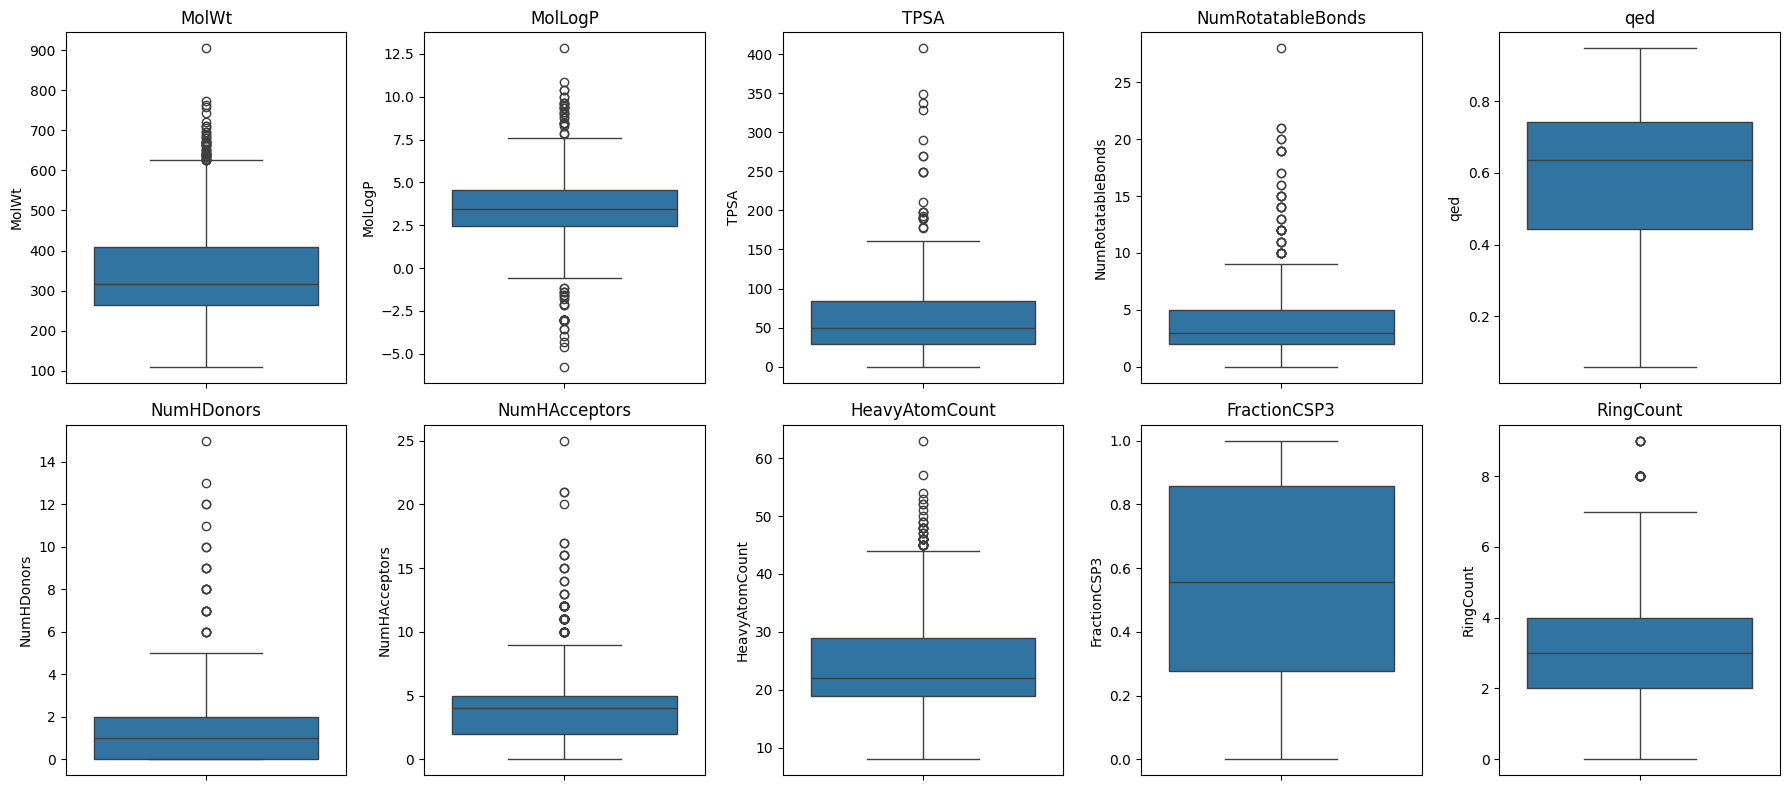

In [ ]:
features = ['MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds', 'qed', 'NumHDonors', 'NumHAcceptors', 'HeavyAtomCount', 'FractionCSP3', 'RingCount']

display(df[features].describe())
display("Skewness:", df[features].skew())
display("Kurtosis:",df[features].kurtosis())

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, feat in enumerate(features):
  sns.histplot(df[feat], kde=True, ax=axes[i//5, i%5])
  axes[i//5, i%5].set_title(feat)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
  sns.boxplot(y=df[feat], ax=axes[i])
  axes[i].set_title(feat)

plt.tight_layout()
plt.show()

In [ ]:
def find_high_cor_features(df, threshold=0.95):
  corr_matrix = df.corr()
  high_corr = corr_matrix[(abs(corr_matrix) > threshold) & (abs(corr_matrix) <= 1.0)].stack().reset_index()
  high_corr.columns = ['var1', 'var2', 'corr']
  high_corr = high_corr[high_corr['var1'] != high_corr['var2']]

  mask = high_corr['var1'] > high_corr['var2']
  high_corr.loc[mask, ['var1', 'var2']] = high_corr.loc[mask, ['var2', 'var1']].values
  unique = high_corr.drop_duplicates(subset=['var1', 'var2'])

  display(unique)
  return unique

find_high_cor_features(df)

X = df.drop(columns=['log_IC50, mM', 'log_CC50, mM', 'log_SI', 'IC50, mM', 'CC50, mM', 'SI'])

top_ic50 = X.corrwith(df[targets[0]]).abs().sort_values(ascending=False).head(25).index
top_cc50 = X.corrwith(df[targets[1]]).abs().sort_values(ascending=False).head(25).index
top_si   = X.corrwith(df[targets[2]]).abs().sort_values(ascending=False).head(25).index

display("Pirson log_IC50:", top_ic50.tolist())
display("Pirson log_CC50:", top_cc50.tolist())
display("Pirson log_SI:  ", top_si.tolist())

mi_ic50 = mutual_info_regression(X, df['log_IC50, mM'])
mi_cc50 = mutual_info_regression(X, df['log_CC50, mM'])
mi_si   = mutual_info_regression(X, df['log_SI'])

top_mi_ic50 = X.columns[np.argsort(mi_ic50)[-25:]]
top_mi_cc50 = X.columns[np.argsort(mi_cc50)[-25:]]
top_mi_si   = X.columns[np.argsort(mi_si)[-25:]]

display("MI log_IC50:", top_mi_ic50.tolist())
display("MI log_CC50:", top_mi_cc50.tolist())
display("MI log_SI:  ", top_mi_si.tolist())


,var1,var2,corr
4,MaxAbsEStateIndex,MaxEStateIndex,1.000000
12,HeavyAtomMolWt,MolWt,0.996850
13,ExactMolWt,MolWt,0.999999
14,MolWt,NumValenceElectrons,0.981224
15,Chi0,MolWt,0.986808
...,...,...,...
300,fr_Ar_OH,fr_phenol_noOrthoHbond,0.990792
303,fr_COO,fr_COO2,1.000000
308,fr_C_O,fr_C_O_noCOO,0.974974
351,fr_nitro_arom,fr_nitro_arom_nonortho,0.956943


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


'Pirson log_IC50:'

['VSA_EState4',
 'Chi2n',
 'PEOE_VSA7',
 'Chi2v',
 'fr_Ar_NH',
 'fr_Nhpyrrole',
 'Chi4v',
 'Chi4n',
 'Chi3n',
 'Chi3v',
 'SlogP_VSA5',
 'Chi1n',
 'Chi1v',
 'MolLogP',
 'fr_nitro',
 'MolMR',
 'Chi0n',
 'Chi0v',
 'BCUT2D_LOGPHI',
 'FpDensityMorgan1',
 'BCUT2D_CHGLO',
 'NumAliphaticCarbocycles',
 'BalabanJ',
 'SMR_VSA4',
 'MinEStateIndex']

'Pirson log_CC50:'

...

['Chi0v',
 'MaxAbsPartialCharge',
 'NumValenceElectrons',
 'BCUT2D_MRLOW',
 'MaxEStateIndex',
 'LabuteASA',
 'MaxAbsEStateIndex',
 'HeavyAtomCount',
 'Kappa2',
 'BCUT2D_LOGPLOW',
 'Chi1',
 'BCUT2D_CHGHI',
 'Chi0n',
 'MaxPartialCharge',
 'BalabanJ',
 'BCUT2D_LOGPHI',
 'AvgIpc',
 'Chi0',
 'VSA_EState8',
 'MinAbsPartialCharge',
 'Kappa1',
 'HeavyAtomMolWt',
 'BCUT2D_CHGLO',
 'MolWt',
 'ExactMolWt']

'MI log_CC50:'

['BCUT2D_MWLOW',
 'BCUT2D_LOGPLOW',
 'Chi1n',
 'Kappa3',
 'MinPartialCharge',
 'BertzCT',
 'BCUT2D_MRLOW',
 'Kappa2',
 'BCUT2D_CHGLO',
 'MaxPartialCharge',
 'MaxAbsPartialCharge',
 'Chi1v',
 'MinAbsPartialCharge',
 'Chi0n',
 'MolMR',
 'HeavyAtomCount',
 'Chi0v',
 'Kappa1',
 'NumValenceElectrons',
 'Chi1',
 'Chi0',
 'LabuteASA',
 'HeavyAtomMolWt',
 'MolWt',
 'ExactMolWt']

'MI log_SI:  '

['MinAbsEStateIndex',
 'VSA_EState8',
 'Chi1n',
 'MolLogP',
 'FpDensityMorgan3',
 'VSA_EState7',
 'SlogP_VSA2',
 'SlogP_VSA4',
 'MinAbsPartialCharge',
 'MinPartialCharge',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'SMR_VSA5',
 'MaxPartialCharge',
 'FractionCSP3',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'SlogP_VSA5',
 'MaxAbsPartialCharge',
 'BCUT2D_LOGPLOW',
 'SMR_VSA4',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI']

Проводим EDA к представленному датасету. Целевые переменные - IC50, CC50 и SI. Представленные датасет имеет 1000 записей и 213 колонок(техническая колонка удаляется сразу). Все данные числовые, поэтому с ними можно работать напрямую. Датасет имеет незначительное количество пропусков: для 3 строчек, что в рамках датасета - отдельные вещества и в силу специфики датасета удалить их будет ошибкой, поэтому заполним пропуски через медиану для сохранении тендеции.

Далее исследуем данные и пытаемся понять какие они. По цифрам и визуально видно что целевые переменные не являются нормальными(IC50 - имеет сильную скошенность, есть много маленьких значений и несколько очень больших, СС50 - умеренную скошенность вправо, а SI - экстремально скошенна), также есть значительные выбросы, однако просто выбросить их нельзя, способность модели к обобщению упадет тк может потеряться важные молекулы, поэтому будем использовать логарифмирование и устойчивые к выбросам модели.

Теперь посмотрим предикторы: 'MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds', 'qed', 'NumHDonors', 'NumHAcceptors','HeavyAtomCount', 'FractionCSP3', 'RingCount', они были выбраны как предположительно самые важные(они описывают базовые и фундаментальные свойства веществ, для анализа - более чем достаточно). Видим что данные разнообразны, часть имеют скошенность, часть имеют нормальные распределения, тоже есть выбросы. Рекомендация использовать логарифмирования и устойчивые модели остается.

При построении матрицы корреляций наблюдается 91 признак с корреляцией 1, поэтому явно нужно отсеять признаки. Тк я не могу идти экспертным путем и отобрать признаки по значению(к сожалению моя кандидатская именно по неорганической химии), попробую отобрать по корреляции Пирсона и по mutial information. Отбираю по 25 признаков как предварительный баланс для скорости и сохранения обощающей способности. Для задач регрессии будут использоваться корреляция Пирсона, для задач классификации будет использоваться лес и поэтому  признаки отбираем по mutial information.

Выводы:
1. Проведен разведавательный анализ датасета. Данные пригодны для моделирования, пропусков мало, разнообразие данных хорошее.
2. Таргеты имеют выбросы, что делает леса предпочтительным выбором(тк устойчивы к выбросам), но базово линейная регрессия тоже будет полезна с учетом логорифмирования данных
3. Для задач классификации по медиане - данные достаточно хорошо сбалансированы(примерно 50/50), однако для задачи "SI > 8" ожидается более слабый результат

